In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn import linear_model
import math
from sklearn.preprocessing import Normalizer
from  matplotlib.ticker import PercentFormatter

In [ ]:
f1 = pd.read_excel("/content/Copy of Feature Book 6_14.xlsx")

In [ ]:
df = pd.read_excel(open('/content/Copy of Feature Book 6_14.xlsx', 'rb'),
              sheet_name='Consolodate')

In [ ]:
df

,District,Month,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal,MUWP,SUWP,TUWP,UWA
0,adilabad,Jan,0.010036,15.545341,31.460215,106.76,376342,157,504,19.13,12.18,31.31,SeverelyUW
1,adilabad,Feb,0.082738,14.430357,32.223413,114.48,393086,157,504,13.36,6.41,19.77,ModeratelyUW
2,adilabad,Mar,0.017025,20.206093,36.552688,137.04,365914,157,504,14.90,7.86,22.76,ModeratelyUW
3,adilabad,Apr,0.301111,24.277963,38.801111,149.88,363796,157,504,17.19,8.73,25.92,ModeratelyUW
4,adilabad,May,0.841726,26.733688,38.320449,150.45,356499,157,504,21.73,14.08,35.81,SeverelyUW
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,yadadri,Aug,5.885389,24.113093,32.641935,169.95,368378,151,907,12.97,3.33,16.30,ModeratelyUW
380,yadadri,Sep,6.356863,23.389020,31.834902,134.74,356486,151,907,16.25,6.85,23.10,ModeratelyUW
381,yadadri,Oct,2.006262,21.767932,33.407590,127.17,327478,151,907,16.77,6.68,23.45,ModeratelyUW
382,yadadri,Nov,1.322549,20.870000,31.235294,122.72,318378,151,907,16.30,5.27,21.57,ModeratelyUW


In [ ]:
df.corr()

,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal,MUWP,SUWP,TUWP
Rainfall,1.000000,0.525034,-0.280544,-0.041649,-0.004311,0.008026,0.031098,-0.002820,0.092366,0.054633
MinTemp,0.525034,1.000000,0.460305,0.030659,0.066559,0.002516,-0.021675,-0.095548,-0.071012,-0.092923
MaxTemp,-0.280544,0.460305,1.000000,0.177565,-0.026789,0.004015,0.012849,-0.247563,-0.172597,-0.233842
Water Level,-0.041649,0.030659,0.177565,1.000000,0.024598,0.544067,0.380421,-0.078798,-0.109645,-0.107660
SumUnits,-0.004311,0.066559,-0.026789,0.024598,1.000000,0.234236,-0.142339,-0.355616,-0.280870,-0.355914
Htotal,0.008026,0.002516,0.004015,0.544067,0.234236,1.000000,0.612985,-0.302416,-0.222178,-0.292542
Rtotal,0.031098,-0.021675,0.012849,0.380421,-0.142339,0.612985,1.000000,-0.222003,-0.138048,-0.199537
MUWP,-0.002820,-0.095548,-0.247563,-0.078798,-0.355616,-0.302416,-0.222003,1.000000,0.567917,0.866058
SUWP,0.092366,-0.071012,-0.172597,-0.109645,-0.280870,-0.222178,-0.138048,0.567917,1.000000,0.903345
TUWP,0.054633,-0.092923,-0.233842,-0.107660,-0.355914,-0.292542,-0.199537,0.866058,0.903345,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   District     384 non-null    object 
 1   Month        384 non-null    object 
 2   Rainfall     384 non-null    float64
 3   MinTemp      384 non-null    float64
 4   MaxTemp      384 non-null    float64
 5   Water Level  384 non-null    float64
 6   SumUnits     384 non-null    int64  
 7   Htotal       384 non-null    int64  
 8   Rtotal       384 non-null    int64  
 9   MUWP         384 non-null    float64
 10  SUWP         384 non-null    float64
 11  TUWP         384 non-null    float64
 12  UWA          384 non-null    object 
dtypes: float64(7), int64(3), object(3)
memory usage: 39.1+ KB


In [ ]:
encoder = LabelEncoder()

In [ ]:
df['UWA'] = encoder.fit_transform(df['UWA'])

In [ ]:
df['District'] = encoder.fit_transform(df['District'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   District     384 non-null    int64  
 1   Month        384 non-null    object 
 2   Rainfall     384 non-null    float64
 3   MinTemp      384 non-null    float64
 4   MaxTemp      384 non-null    float64
 5   Water Level  384 non-null    float64
 6   SumUnits     384 non-null    int64  
 7   Htotal       384 non-null    int64  
 8   Rtotal       384 non-null    int64  
 9   MUWP         384 non-null    float64
 10  SUWP         384 non-null    float64
 11  TUWP         384 non-null    float64
 12  UWA          384 non-null    int64  
dtypes: float64(7), int64(5), object(1)
memory usage: 39.1+ KB


In [ ]:
df['Month'] = encoder.fit_transform(df['Month'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   District     384 non-null    int64  
 1   Month        384 non-null    int64  
 2   Rainfall     384 non-null    float64
 3   MinTemp      384 non-null    float64
 4   MaxTemp      384 non-null    float64
 5   Water Level  384 non-null    float64
 6   SumUnits     384 non-null    int64  
 7   Htotal       384 non-null    int64  
 8   Rtotal       384 non-null    int64  
 9   MUWP         384 non-null    float64
 10  SUWP         384 non-null    float64
 11  TUWP         384 non-null    float64
 12  UWA          384 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 39.1 KB


In [ ]:
df.describe()

,District,Month,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal,MUWP,SUWP,TUWP,UWA
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,3.840000e+02,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000
mean,15.500000,5.500000,3.128021,21.697264,33.273870,230.585937,6.444177e+05,182.656250,800.375000,15.359245,6.931146,22.290391,0.312500
std,9.245138,3.456556,4.156694,3.296611,2.645980,168.883980,5.920618e+05,58.053874,340.347089,2.977088,3.470103,5.713033,0.671112
min,0.000000,0.000000,0.000000,13.996595,29.112366,34.940000,1.104430e+05,104.000000,119.000000,6.130000,1.510000,7.640000,0.000000
25%,7.750000,2.750000,0.047541,19.215161,31.307339,109.605000,3.378468e+05,129.750000,576.000000,13.195000,4.577500,17.687500,0.000000
50%,15.500000,5.500000,1.004131,22.777121,32.354782,174.255000,5.028425e+05,176.000000,821.000000,15.385000,6.310000,22.125000,0.000000
75%,23.250000,8.250000,5.834341,24.358595,35.430327,307.060000,7.056422e+05,229.750000,1026.000000,17.452500,8.092500,25.730000,0.000000
max,31.000000,11.000000,18.161121,27.611584,39.304137,1075.850000,3.945418e+06,294.000000,1654.000000,23.410000,23.140000,40.890000,2.000000


In [ ]:
df.head()

,District,Month,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal,MUWP,SUWP,TUWP,UWA
0,0,4,0.010036,15.545341,31.460215,106.76,376342,157,504,19.13,12.18,31.31,2
1,0,3,0.082738,14.430357,32.223413,114.48,393086,157,504,13.36,6.41,19.77,0
2,0,7,0.017025,20.206093,36.552688,137.04,365914,157,504,14.90,7.86,22.76,0
3,0,0,0.301111,24.277963,38.801111,149.88,363796,157,504,17.19,8.73,25.92,0
4,0,8,0.841726,26.733688,38.320449,150.45,356499,157,504,21.73,14.08,35.81,2


In [ ]:
df.corr()

,District,Month,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal,MUWP,SUWP,TUWP,UWA
District,1.000000e+00,-5.608045e-16,-0.039491,-0.049225,-0.051799,0.111478,-0.169191,4.731413e-02,3.308255e-01,-0.023873,-0.138877,-0.096794,-0.063964
Month,-5.608045e-16,1.000000e+00,0.183144,0.238984,-0.077914,-0.089370,-0.005322,1.386781e-17,-1.269152e-16,0.212446,0.165477,0.211218,0.069784
Rainfall,-3.949111e-02,1.831441e-01,1.000000,0.525034,-0.280544,-0.041649,-0.004311,8.025743e-03,3.109756e-02,-0.002820,0.092366,0.054633,0.065890
MinTemp,-4.922498e-02,2.389844e-01,0.525034,1.000000,0.460305,0.030659,0.066559,2.515845e-03,-2.167500e-02,-0.095548,-0.071012,-0.092923,-0.031479
MaxTemp,-5.179851e-02,-7.791375e-02,-0.280544,0.460305,1.000000,0.177565,-0.026789,4.015435e-03,1.284867e-02,-0.247563,-0.172597,-0.233842,-0.069276
Water Level,1.114776e-01,-8.937028e-02,-0.041649,0.030659,0.177565,1.000000,0.024598,5.440670e-01,3.804209e-01,-0.078798,-0.109645,-0.107660,-0.130391
SumUnits,-1.691910e-01,-5.322180e-03,-0.004311,0.066559,-0.026789,0.024598,1.000000,2.342357e-01,-1.423385e-01,-0.355616,-0.280870,-0.355914,-0.172335
Htotal,4.731413e-02,1.386781e-17,0.008026,0.002516,0.004015,0.544067,0.234236,1.000000e+00,6.129847e-01,-0.302416,-0.222178,-0.292542,-0.153382
Rtotal,3.308255e-01,-1.269152e-16,0.031098,-0.021675,0.012849,0.380421,-0.142339,6.129847e-01,1.000000e+00,-0.222003,-0.138048,-0.199537,-0.090568
MUWP,-2.387271e-02,2.124465e-01,-0.002820,-0.095548,-0.247563,-0.078798,-0.355616,-3.024162e-01,-2.220027e-01,1.000000,0.567917,0.866058,0.213887


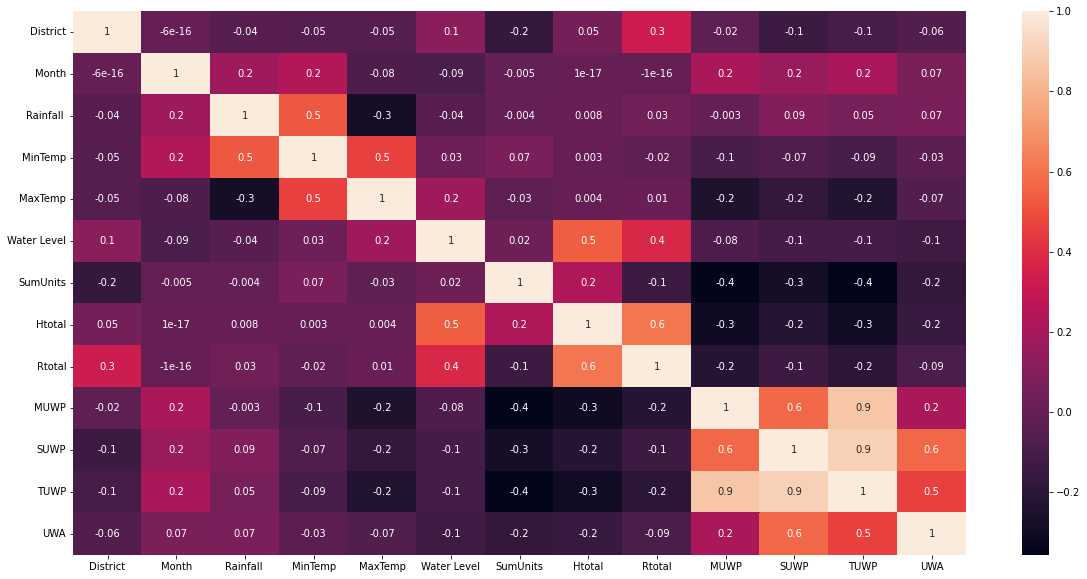

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True, fmt='.1g')


In [ ]:
import statsmodels.api as sm

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:

x = df[['District','MinTemp','Water Level','Htotal']]
y = df['TUWP']

regr = linear_model.LinearRegression()
regr.fit(x, y)

print('Intercept: \n', regr.intercept_)
print('Coefficients: \n', regr.coef_)
model = sm.OLS(y, x).fit()
predictions = model.predict(x)

print_model = model.summary()
print(print_model)

Intercept: 
 32.297631968718214
Coefficients: 
 [-0.05914045 -0.17246126  0.00300912 -0.03308119]
                                 OLS Regression Results                                
Dep. Variable:                   TUWP   R-squared (uncentered):                   0.911
Model:                            OLS   Adj. R-squared (uncentered):              0.910
Method:                 Least Squares   F-statistic:                              977.0
Date:                Tue, 10 May 2022   Prob (F-statistic):                   1.88e-198
Time:                        08:00:26   Log-Likelihood:                         -1283.8
No. Observations:                 384   AIC:                                      2576.
Df Residuals:                     380   BIC:                                      2591.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef

In [ ]:
df_max_scaled = df.copy()
  
# apply normalization techniques
for column in df_max_scaled.columns:
    df_max_scaled[column] = df_max_scaled[column]  / df_max_scaled[column].abs().max()
      
# view normalized data
display(df_max_scaled)

,District,Month,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal,MUWP,SUWP,TUWP,UWA
0,0.0,0.363636,0.000553,0.563001,0.800430,0.099233,0.095387,0.534014,0.304716,0.817172,0.526361,0.765713,1.0
1,0.0,0.272727,0.004556,0.522620,0.819848,0.106409,0.099631,0.534014,0.304716,0.570696,0.277010,0.483492,0.0
2,0.0,0.636364,0.000937,0.731798,0.929996,0.127378,0.092744,0.534014,0.304716,0.636480,0.339672,0.556615,0.0
3,0.0,0.000000,0.016580,0.879267,0.987202,0.139313,0.092207,0.534014,0.304716,0.734302,0.377269,0.633896,0.0
4,0.0,0.727273,0.046348,0.968206,0.974972,0.139843,0.090358,0.534014,0.304716,0.928236,0.608470,0.875764,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,1.0,0.090909,0.324065,0.873296,0.830496,0.157968,0.093369,0.513605,0.548368,0.554037,0.143907,0.398630,0.0
380,1.0,1.000000,0.350026,0.847073,0.809963,0.125241,0.090354,0.513605,0.548368,0.694148,0.296024,0.564930,0.0
381,1.0,0.909091,0.110470,0.788362,0.849976,0.118204,0.083002,0.513605,0.548368,0.716361,0.288678,0.573490,0.0
382,1.0,0.818182,0.072823,0.755842,0.794708,0.114068,0.080696,0.513605,0.548368,0.696284,0.227744,0.527513,0.0


In [ ]:
x = df[['District','MinTemp','Water Level','Htotal']]
y = df['TUWP']

regr = linear_model.LinearRegression()
regr.fit(x, y)

print('Intercept: \n', regr.intercept_)
print('Coefficients: \n', regr.coef_)
model = sm.OLS(y, x).fit()
predictions = model.predict(x)

print_model = model.summary()
print(print_model)

Intercept: 
 32.297631968718214
Coefficients: 
 [-0.05914045 -0.17246126  0.00300912 -0.03308119]
                                 OLS Regression Results                                
Dep. Variable:                   TUWP   R-squared (uncentered):                   0.911
Model:                            OLS   Adj. R-squared (uncentered):              0.910
Method:                 Least Squares   F-statistic:                              977.0
Date:                Tue, 10 May 2022   Prob (F-statistic):                   1.88e-198
Time:                        08:00:31   Log-Likelihood:                         -1283.8
No. Observations:                 384   AIC:                                      2576.
Df Residuals:                     380   BIC:                                      2591.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler,OrdinalEncoder
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import preprocessing 

from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,plot_roc_curve,roc_curve,roc_auc_score,plot_confusion_matrix,recall_score,precision_score

In [ ]:
x = df.drop(columns=['MUWP','SUWP','TUWP','UWA','Month','District'])
x.head()

,Rainfall,MinTemp,MaxTemp,Water Level,SumUnits,Htotal,Rtotal
0,0.010036,15.545341,31.460215,106.76,376342,157,504
1,0.082738,14.430357,32.223413,114.48,393086,157,504
2,0.017025,20.206093,36.552688,137.04,365914,157,504
3,0.301111,24.277963,38.801111,149.88,363796,157,504
4,0.841726,26.733688,38.320449,150.45,356499,157,504


In [ ]:
y = df['UWA']
y.head()

0    2
1    0
2    0
3    0
4    2
Name: UWA, dtype: int64

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.4)

In [ ]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_pred, y_test)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       125
           1       0.27      0.36      0.31        11
           2       0.40      0.33      0.36        18

    accuracy                           0.75       154
   macro avg       0.51      0.51      0.51       154
weighted avg       0.76      0.75      0.76       154



In [ ]:
model = XGBClassifier()
model.fit(x_train, y_train)
xgb_y_pred = clf.predict(x_test)
xgb_cm = confusion_matrix(y_test,xgb_y_pred)
xgb_accuracy = accuracy_score(y_test,xgb_y_pred)
print(xgb_accuracy)

0.7532467532467533


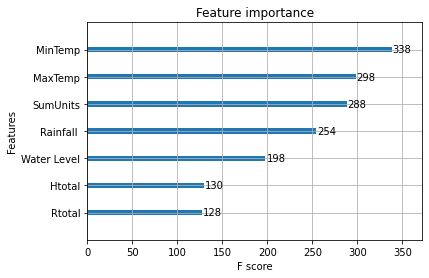

In [ ]:
from xgboost import plot_importance
plot_importance(model)